In [62]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Remove future Warnings
import warnings
warnings.filterwarnings("ignore")

# 1. Load the dataset

In [63]:
df=pd.read_csv(r"C:\Users\jooph\Downloads\CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### Dataset Infromation

In [64]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

### check null values

In [65]:
df.isnull().sum().value_counts()

0    26
Name: count, dtype: int64

no null value in the dataset

In [66]:
df.shape

(205, 26)

In [67]:
df.size

5330

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [70]:
df.dtypes.value_counts()

object     10
int64       8
float64     8
Name: count, dtype: int64

# 2. Data Preprocessing

In [71]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

Drop unnecessary column

Car_ID does not affect price prediction.

In [72]:
df.drop('car_ID',axis=1,inplace=True)

In [73]:
df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### Separate target and features

In [74]:
X = df.drop('price', axis=1)

y = df['price']

In [75]:
X.columns

Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object')

### Find categorical columns

In [76]:
categorical_columns = X.select_dtypes(
    include=['object']
).columns

categorical_columns

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')

### Apply LabelEncoder only on features

In [77]:
le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

In [78]:
X.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
0,3,2,1,0,1,0,2,0,88.6,168.8,...,2,130,5,3.47,2.68,9.0,111,5000,21,27
1,3,3,1,0,1,0,2,0,88.6,168.8,...,2,130,5,3.47,2.68,9.0,111,5000,21,27
2,1,1,1,0,1,2,2,0,94.5,171.2,...,3,152,5,2.68,3.47,9.0,154,5000,19,26
3,2,4,1,0,0,3,1,0,99.8,176.6,...,2,109,5,3.19,3.40,10.0,102,5500,24,30
4,2,5,1,0,0,3,0,0,99.4,176.6,...,1,136,5,3.19,3.40,8.0,115,5500,18,22


### Check outliers only in encoded features

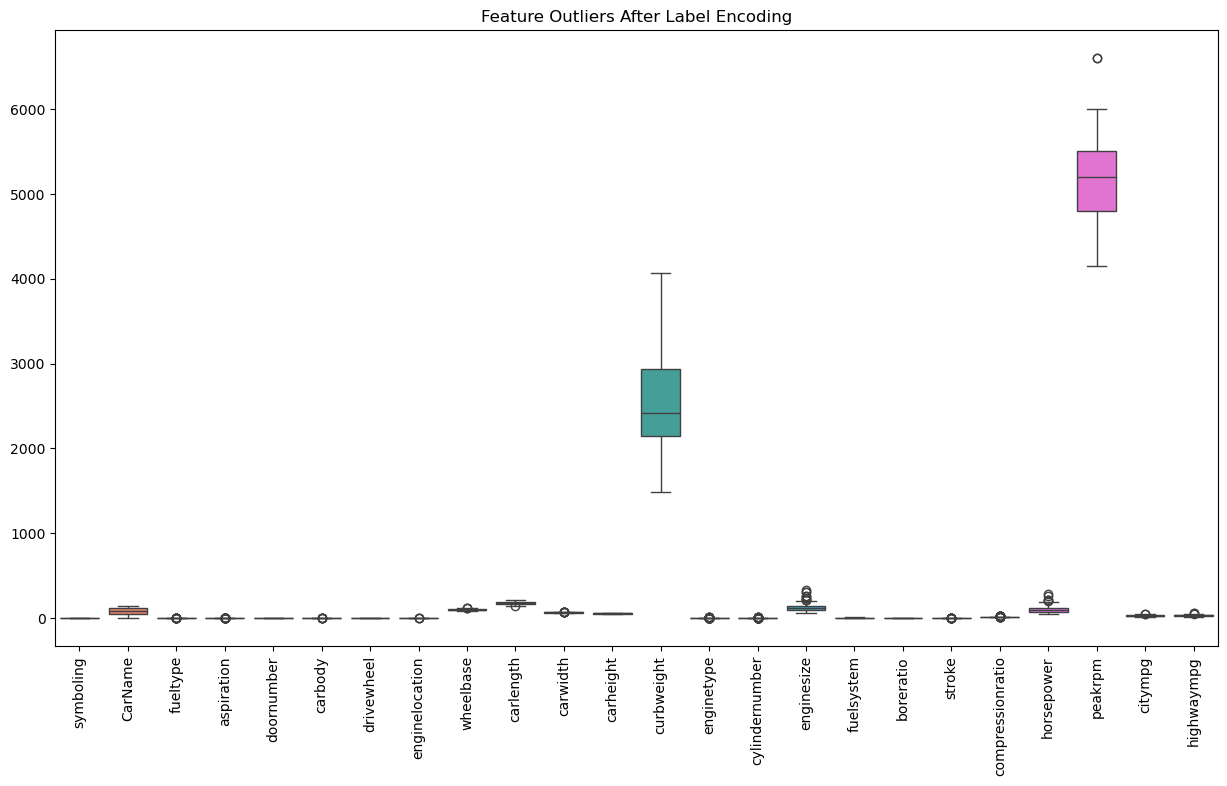

In [79]:
plt.figure(figsize=(15,8))

sns.boxplot(
    data=X
)

plt.xticks(rotation=90)

plt.title("Feature Outliers After Label Encoding")

plt.show()

In [80]:
for col in X.columns:

    Q1 = X[col].quantile(0.25)

    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1


    outliers = X[
        (X[col] < Q1 - 1.5*IQR) |
        (X[col] > Q3 + 1.5*IQR)
    ]


    print(
        col,
        "Outliers:",
        len(outliers)
    )

symboling Outliers: 0
CarName Outliers: 0
fueltype Outliers: 20
aspiration Outliers: 37
doornumber Outliers: 0
carbody Outliers: 6
drivewheel Outliers: 0
enginelocation Outliers: 3
wheelbase Outliers: 3
carlength Outliers: 1
carwidth Outliers: 8
carheight Outliers: 0
curbweight Outliers: 0
enginetype Outliers: 57
cylindernumber Outliers: 46
enginesize Outliers: 10
fuelsystem Outliers: 0
boreratio Outliers: 0
stroke Outliers: 20
compressionratio Outliers: 28
horsepower Outliers: 6
peakrpm Outliers: 2
citympg Outliers: 2
highwaympg Outliers: 3


### Treat the outliers

In [81]:

for col in X.columns:

    Q1 = X[col].quantile(0.25)

    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1


    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR


    X[col] = np.where(
        X[col] < lower_limit,
        lower_limit,
        X[col]
    )


    X[col] = np.where(
        X[col] > upper_limit,
        upper_limit,
        X[col]
    )

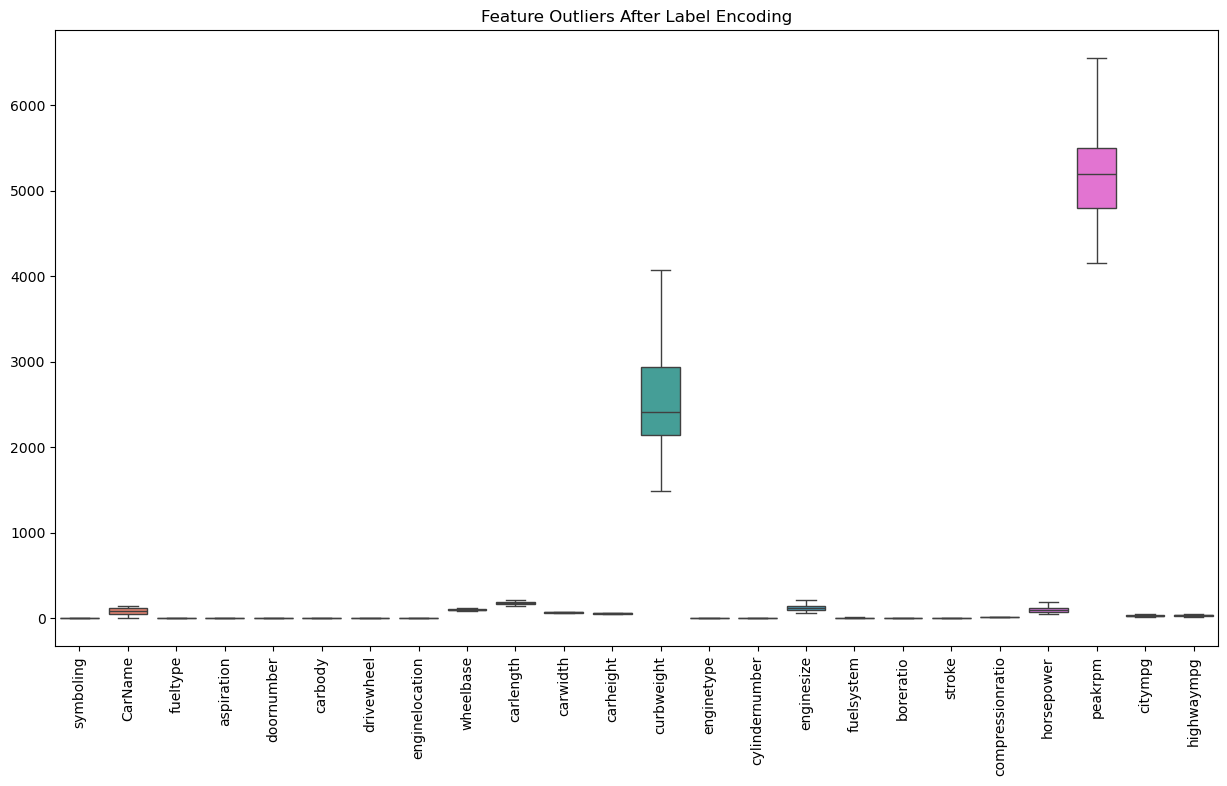

In [82]:
plt.figure(figsize=(15,8))

sns.boxplot(
    data=X
)

plt.xticks(rotation=90)

plt.title("Feature Outliers After Label Encoding")

plt.show()

### Train-Test Split

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Feature Scaling
(Important for SVR)

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# 3.Model Implementation

In [85]:
# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

## Linear Regression

### Create Model

In [86]:
lr_model = LinearRegression()

### Train Model

In [87]:
lr_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](24,)","[ 16.41, -29.74, 0. ,..., 1.49,-105.49, 124.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](24,)","['symboling','CarName','fueltype',...,'peakrpm','citympg','highwaympg']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6.051e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,24
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,19


### Make Predictions

In [88]:
y_pred_lr = lr_model.predict(
    X_test
)

In [89]:
lr_result = pd.DataFrame({

    "Actual Price": y_test.values,
    "Predicted Price": y_pred_lr
})

lr_result.head()

,Actual Price,Predicted Price
0,30760.000,28539.585391
1,17859.167,20140.882801
2,9549.000,9869.792630
3,11850.000,14889.784507
4,28248.000,26754.883311


### Evaluate Linear Regression

In [90]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(
    y_test,
    y_pred_lr
)
mse = mean_squared_error(
    y_test,
    y_pred_lr
)
mae = mean_absolute_error(
    y_test,
    y_pred_lr
)
print("Linear Regression Results")
print("-------------------------")
print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)

Linear Regression Results
-------------------------
R2 Score: 0.8330173703564678
MSE: 13182280.201119147
MAE: 2355.207187142929


## Decision Tree

### Create Model

In [91]:
dt_model=DecisionTreeRegressor(random_state=42)

### Train model

In [92]:
dt_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

### Make Predictions

In [93]:
y_pred_dt =dt_model.predict(
    X_test
)

In [94]:
dt_result = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": y_pred_dt

})


dt_result.head()

,Actual Price,Predicted Price
0,30760.000,36880.0
1,17859.167,18620.0
2,9549.000,8949.0
3,11850.000,12170.0
4,28248.000,35056.0


### Evaluate Decision Tree

In [112]:
r2 = r2_score(
    y_test,
    y_pred_dt
)
mse = mean_squared_error(
    y_test,
    y_pred_dt
)
mae = mean_absolute_error(
    y_test,
    y_pred_dt
)
print("Decision Tree Results")
print("-------------------------")
print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)

Decision Tree Results
-------------------------
R2 Score: 0.8865883516021122
MSE: 8953171.539119244
MAE: 1970.8861707317074


##  Random Forest

### Create Model

In [96]:
rf_model=RandomForestRegressor(random_state=42)

### Train model

In [107]:
rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### Make Predictions

In [108]:
y_pred_rf =rf_model.predict(
    X_test
)

In [119]:
rf_result = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": y_pred_rf

})


rf_result.head()

,Actual Price,Predicted Price
0,30760.000,36641.29
1,17859.167,19077.92
2,9549.000,8950.57
3,11850.000,12862.38
4,28248.000,28701.80


### Evaluate Random Forest

In [111]:
r2 = r2_score(
    y_test,
    y_pred_rf
)
mse = mean_squared_error(
    y_test,
    y_pred_rf
)
mae = mean_absolute_error(
    y_test,
    y_pred_rf
)
print("Random Forest Results")
print("-------------------------")
print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)

Random Forest Results
-------------------------
R2 Score: 0.9552551919504759
MSE: 3532335.060917903
MAE: 1323.4040975609755


## GradientBoostingRegressor

### Create Model

In [101]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

### train model

In [102]:
gb_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

### Make Predictions

In [103]:
y_pred_gb = gb_model.predict(
    X_test
)

In [118]:
gb_result = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": y_pred_gb

})


gb_result.head()

,Actual Price,Predicted Price
0,30760.000,37026.737577
1,17859.167,20163.507524
2,9549.000,8452.969036
3,11850.000,12964.977535
4,28248.000,33179.792469


### Evaluate Gradient Boosting

In [105]:
r2 = r2_score(
    y_test,
    y_pred_gb
)
mse = mean_squared_error(
    y_test,
    y_pred_gb
)
mae = mean_absolute_error(
    y_test,
    y_pred_gb
)
print("Gradient Boosting Results")
print("--------------------------")
print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)

Gradient Boosting Results
--------------------------
R2 Score: 0.9204760197046088
MSE: 6277942.760872846
MAE: 1751.618274309139


## SVR Model

### Create SVR Model

In [113]:
svm_model = SVR(
    kernel='rbf'
)

In [114]:
### rbf kernel helps capture non-linear relationships.

### Train model

In [115]:
svm_model.fit(
    X_train_scaled,
    y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


### Make Prediction

In [116]:
y_pred_svm = svm_model.predict(
    X_test_scaled
)

In [117]:
svm_result = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": y_pred_svm

})


dt_result.head()

,Actual Price,Predicted Price
0,30760.000,36641.29
1,17859.167,19077.92
2,9549.000,8950.57
3,11850.000,12862.38
4,28248.000,28701.80


### Evaluate SVR

In [120]:
r2 = r2_score(
    y_test,
    y_pred_svm
)


mse = mean_squared_error(
    y_test,
    y_pred_svm
)


mae = mean_absolute_error(
    y_test,
    y_pred_svm
)


print("Support Vector Regression Results")
print("--------------------------------")
print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)

Support Vector Regression Results
--------------------------------
R2 Score: -0.09967607870083506
MSE: 86812851.31781879
MAE: 5696.033688725498


In [121]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd


evaluation_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Support Vector Regressor"
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_svm)
    ],

    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_gb),
        mean_squared_error(y_test, y_pred_svm)
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_svm)
    ]

})


evaluation_df

,Model,R2 Score,MSE,MAE
0,Linear Regression,0.833017,1.318228e+07,2355.207187
1,Decision Tree,0.886588,8.953172e+06,1970.886171
2,Random Forest,0.955255,3.532335e+06,1323.404098
3,Gradient Boosting,0.920476,6.277943e+06,1751.618274
4,Support Vector Regressor,-0.099676,8.681285e+07,5696.033689


# 4.Model Comparision

In [122]:
evaluation_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score,MSE,MAE
2,Random Forest,0.955255,3.532335e+06,1323.404098
3,Gradient Boosting,0.920476,6.277943e+06,1751.618274
1,Decision Tree,0.886588,8.953172e+06,1970.886171
0,Linear Regression,0.833017,1.318228e+07,2355.207187
4,Support Vector Regressor,-0.099676,8.681285e+07,5696.033689


### Visualization

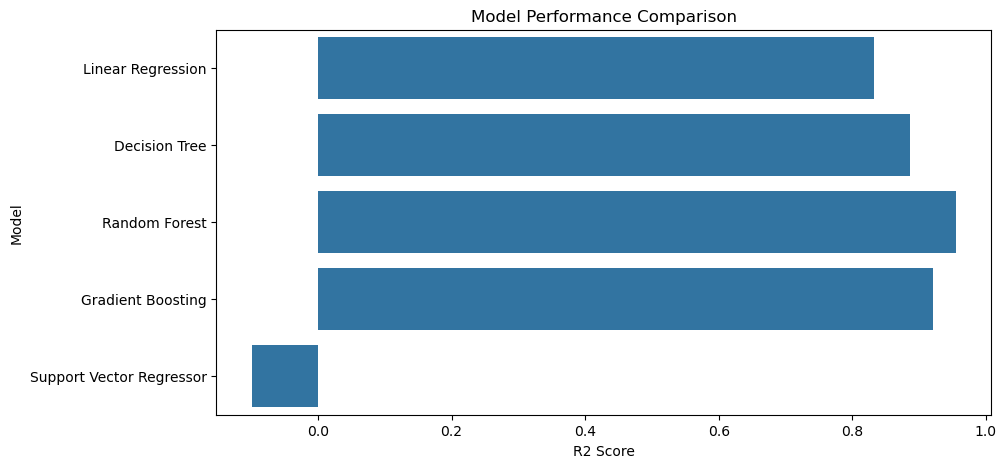

In [124]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="R2 Score",
    y="Model",
    data=evaluation_df
)

plt.title(
    "Model Performance Comparison"
)

plt.show()

### Best Model Selection

In [126]:
best_model = evaluation_df.loc[
    evaluation_df['R2 Score'].idxmax()
]


best_model

Model        Random Forest
R2 Score          0.955255
MSE         3532335.060918
MAE            1323.404098
Name: 2, dtype: object

# 5.Feature Importance Analysis

In [127]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)


importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})


importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
15,enginesize,0.547859
12,curbweight,0.295802
23,highwaympg,0.045152
20,horsepower,0.032395
1,CarName,0.020076
10,carwidth,0.012664
9,carlength,0.007185
8,wheelbase,0.006493
22,citympg,0.004994
21,peakrpm,0.004942


## Feature Importance Plot

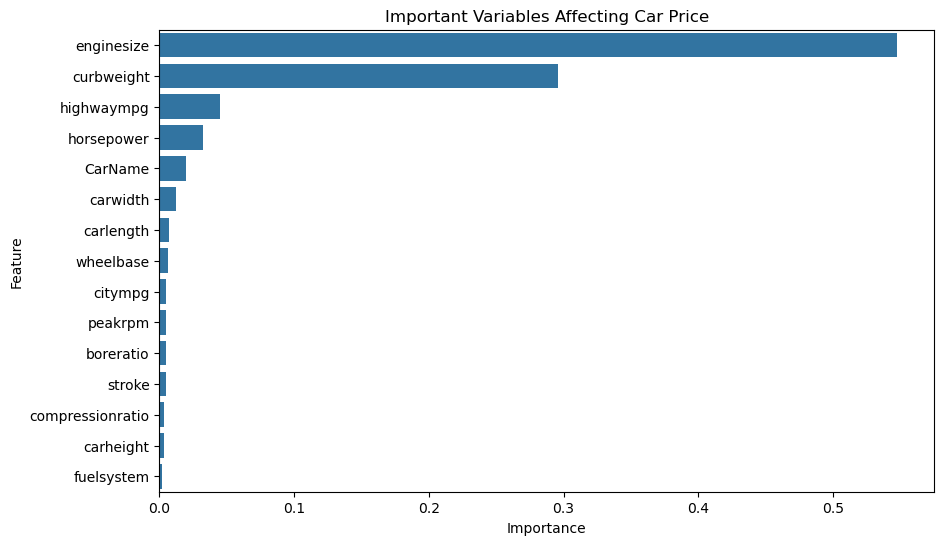

In [128]:
top_features = importance.sort_values(
    by="Importance",
    ascending=False
).head(15)


plt.figure(figsize=(10,6))


sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)


plt.title(
"Important Variables Affecting Car Price"
)

plt.show()

# 6. Hyperparameter Tuning

In [129]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
parameters = {

'n_estimators':[100,200,300],

'max_depth':[5,10,15],

'min_samples_split':[2,5]

}

In [132]:
grid = GridSearchCV(

RandomForestRegressor(
random_state=42
),

parameters,

cv=5,

scoring='r2',

n_jobs=-1

)


grid.fit(
X_train,
y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls 

### Best Parameters

In [133]:
grid.best_params_

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}

### Tuned Model Evaluation

In [134]:
best_rf = grid.best_estimator_


prediction = best_rf.predict(
    X_test
)


print(
"R2 Score:",
r2_score(
    y_test,
    prediction
))


print(
"MSE:",
mean_squared_error(
    y_test,
    prediction
))


print(
"MAE:",
mean_absolute_error(
    y_test,
    prediction
))

R2 Score: 0.9563414997385833
MSE: 3446577.5562118185
MAE: 1298.1452818428186
